First 5 Rows:
         Date      Open      High       Low     Close      Volume
0  2004-01-02  0.196417  0.199083  0.192333  0.192333   436416000
1  2004-01-05  0.195250  0.199917  0.193500  0.198583   575292000
2  2004-01-06  0.198000  0.209417  0.197083  0.206667  1093344000
3  2004-01-07  0.204333  0.209500  0.202917  0.208500   673032000
4  2004-01-08  0.211083  0.212083  0.207250  0.209250   433752000

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5033 entries, 0 to 5032
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5033 non-null   object 
 1   Open    5033 non-null   float64
 2   High    5033 non-null   float64
 3   Low     5033 non-null   float64
 4   Close   5033 non-null   float64
 5   Volume  5033 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 236.1+ KB
None

Statistical Summary:
              Open         High          Low        Close        Volume
count  503

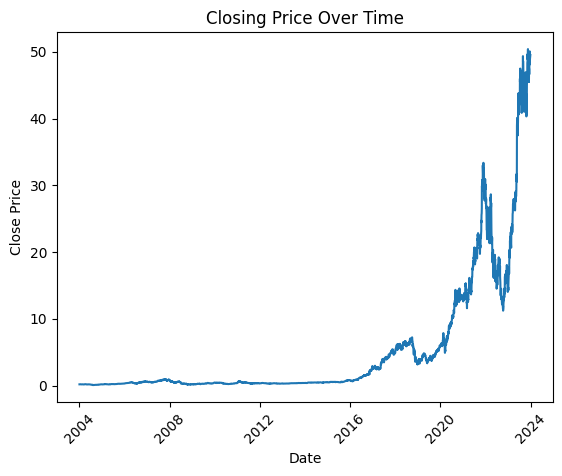

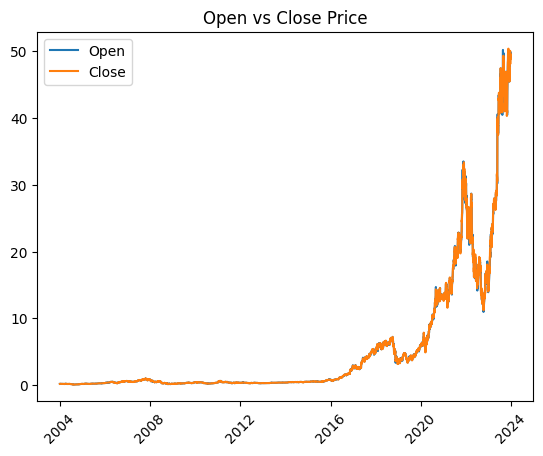

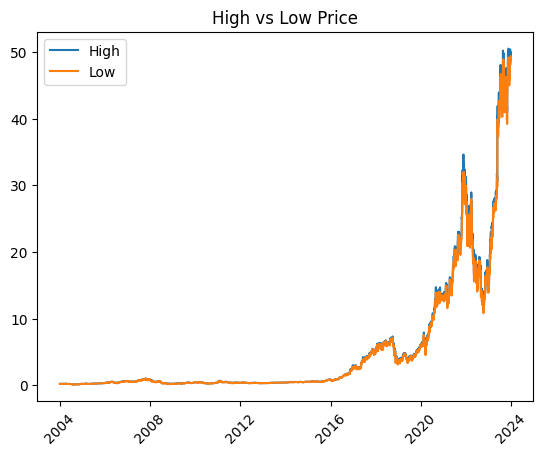

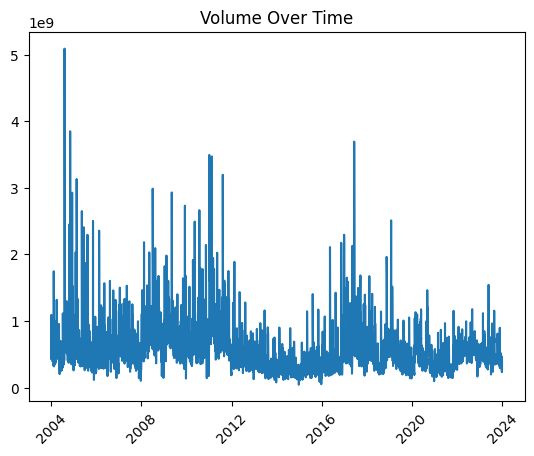

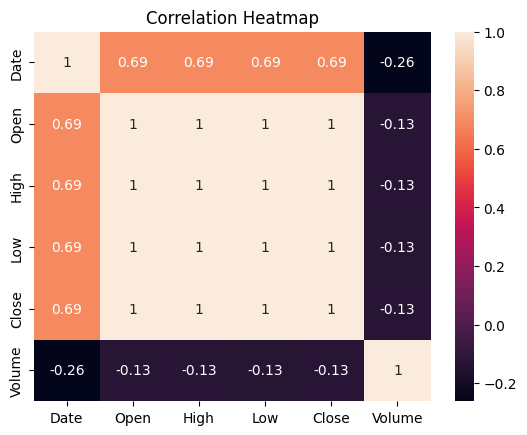

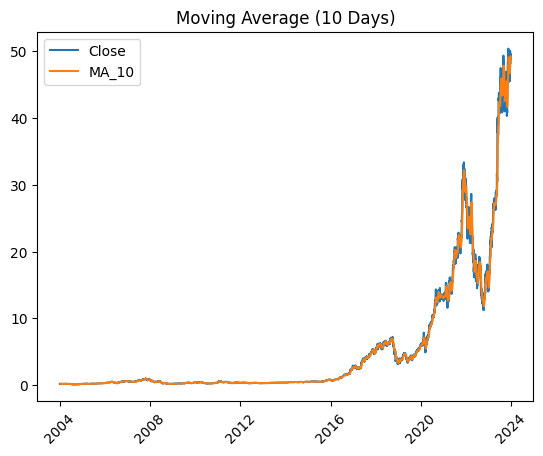


 Model Evaluation:

Mean Squared Error (MSE):
0.06628604304882971

R2 Score:
0.9995201045282917


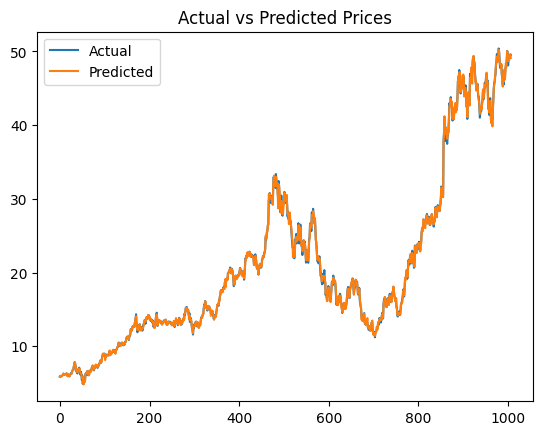

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("nvidia_stock_prices.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

df.ffill(inplace=True)

# Convert Date & Sort
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')


# Closing Price Trend
plt.figure()
plt.plot(df['Date'], df['Close'])
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.show()

# Open vs Close
plt.figure()
plt.plot(df['Date'], df['Open'], label='Open')
plt.plot(df['Date'], df['Close'], label='Close')
plt.legend()
plt.title("Open vs Close Price")
plt.xticks(rotation=45)
plt.show()

# High vs Low
plt.figure()
plt.plot(df['Date'], df['High'], label='High')
plt.plot(df['Date'], df['Low'], label='Low')
plt.legend()
plt.title("High vs Low Price")
plt.xticks(rotation=45)
plt.show()

# Volume Trend
plt.figure()
plt.plot(df['Date'], df['Volume'])
plt.title("Volume Over Time")
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Moving Average 
df['MA_10'] = df['Close'].rolling(window=10).mean()

plt.figure()
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA_10'], label='MA_10')
plt.legend()
plt.title("Moving Average (10 Days)")
plt.xticks(rotation=45)
plt.show()

features = ['Open', 'High', 'Low', 'Volume']
X = df[features]
y = df['Close']


split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("\n Model Evaluation:")

print("\nMean Squared Error (MSE):")
print(mean_squared_error(y_test, y_pred))

print("\nR2 Score:")
print(r2_score(y_test, y_pred))

plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()